This example demonstrates how to simulate standard problem 4 using **MicroMagnetic.jl**. We start by relaxing the system to achieve a stable magnetization configuration,
followed by applying an external magnetic field to study its effects.

Import necessary modules

In [1]:
using MicroMagnetic
using CairoMakie
using DelimitedFiles

Enable GPU acceleration

In [2]:
@using_gpu()

Define the system geometry: a film with thickness t = 3 nm, length L = 500 nm, and width d = 125 nm.

In [3]:
mesh = FDMesh(; nx=200, ny=50, nz=1, dx=2.5e-9, dy=2.5e-9, dz=3e-9);

## Step 1: Relaxing the System
The first step in our simulation is to relax the system to obtain a stable magnetization configuration, often referred to as an "S" state. We encapsulate this process in the `relax_system` function.

In [4]:
function relax_system(mesh)
   sim = Sim(mesh; driver="SD", name="std4")

   Ms = 8e5
   A = 1.3e-11

   set_Ms(sim, Ms)   # Set saturation magnetization
   add_exch(sim, A)  # Add exchange interaction
   add_demag(sim)    # Add demagnetization

   init_m0(sim, (1, 0.25, 0.1))  # Initialize magnetization
   relax(sim; stopping_dmdt=0.01)  # Relax the system

   return sim
end

relax_system (generic function with 1 method)

The `relax_system` function takes a mesh as input and performs the following steps:

**Simulation Initialization:**
The function initializes a simulation (`sim`) using the given mesh and sets the driver to "SD" (Steepest Descent), which is typically used for relaxation processes. The simulation is named "std4" for consistency with standard problem 4.

**Material Parameters Setup:**
The saturation magnetization `Ms` and exchange constant `A` are set up using `set_Ms` and `add_exch` functions, respectively. Demagnetization effects are added using `add_demag`.

**Initial Magnetization:**
The initial magnetization vector `m0` is set using `init_m0`. In this case, it is initialized with a vector `(1, 0.25, 0.1)`.

**Relaxation:**
The system is relaxed using the `relax` function, which iteratively minimizes the system's energy until the change in magnetization (`dm/dt`) falls below a specified threshold (`stopping_dmdt=0.01`).

Relax the system to obtain a stable magnetization configuration

In [5]:
sim = relax_system(mesh);

[ Info: MicroSim has been created.
[ Info: Exchange has been added.
[ Info: Running Driver : MicroMagnetic.EnergyMinimization{Float64}.
[ Info: max_dmdt is less than stopping_dmdt=0.01 @steps=370, Done!


## Step 2: Applying an External Field
After obtaining the stable "S" state, the next step is to apply an external magnetic field and observe the magnetization dynamics.
Plot the magnetization distribution using the `plot_m` function

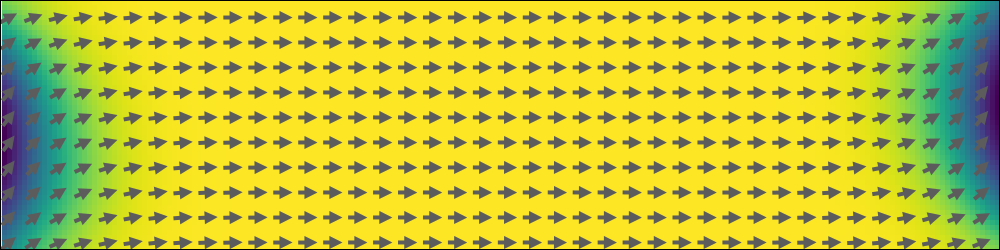

In [6]:
plot_m(sim; component='x')

Apply an external field starting from the relaxed "S" state

In [7]:
set_driver(sim; driver="LLG", alpha=0.02, gamma=2.211e5)
add_zeeman(sim, (-24.6mT, 4.3mT, 0))  # Apply external magnetic field
if !isfile("std4.jld2")
   run_sim(sim; steps=100, dt=1e-11)  # Run the simulation for 10 steps
end

[ Info: The driver LLG is used!
[ Info: Static Zeeman has been added.


## Step 3: Visualizing the Results
By default, `run_sim` generates a `jld2` file, which stores the magnetization data. You can create a movie from this data to visualize the magnetization dynamics.
Generate a movie based on the simulation results

In [8]:
jld2movie("std4.jld2"; output="assets/std4.mp4", component='x');

![](./assets/std4.mp4)

Finally, we plot the time evolution of the magnetization using the plot_m_ts function

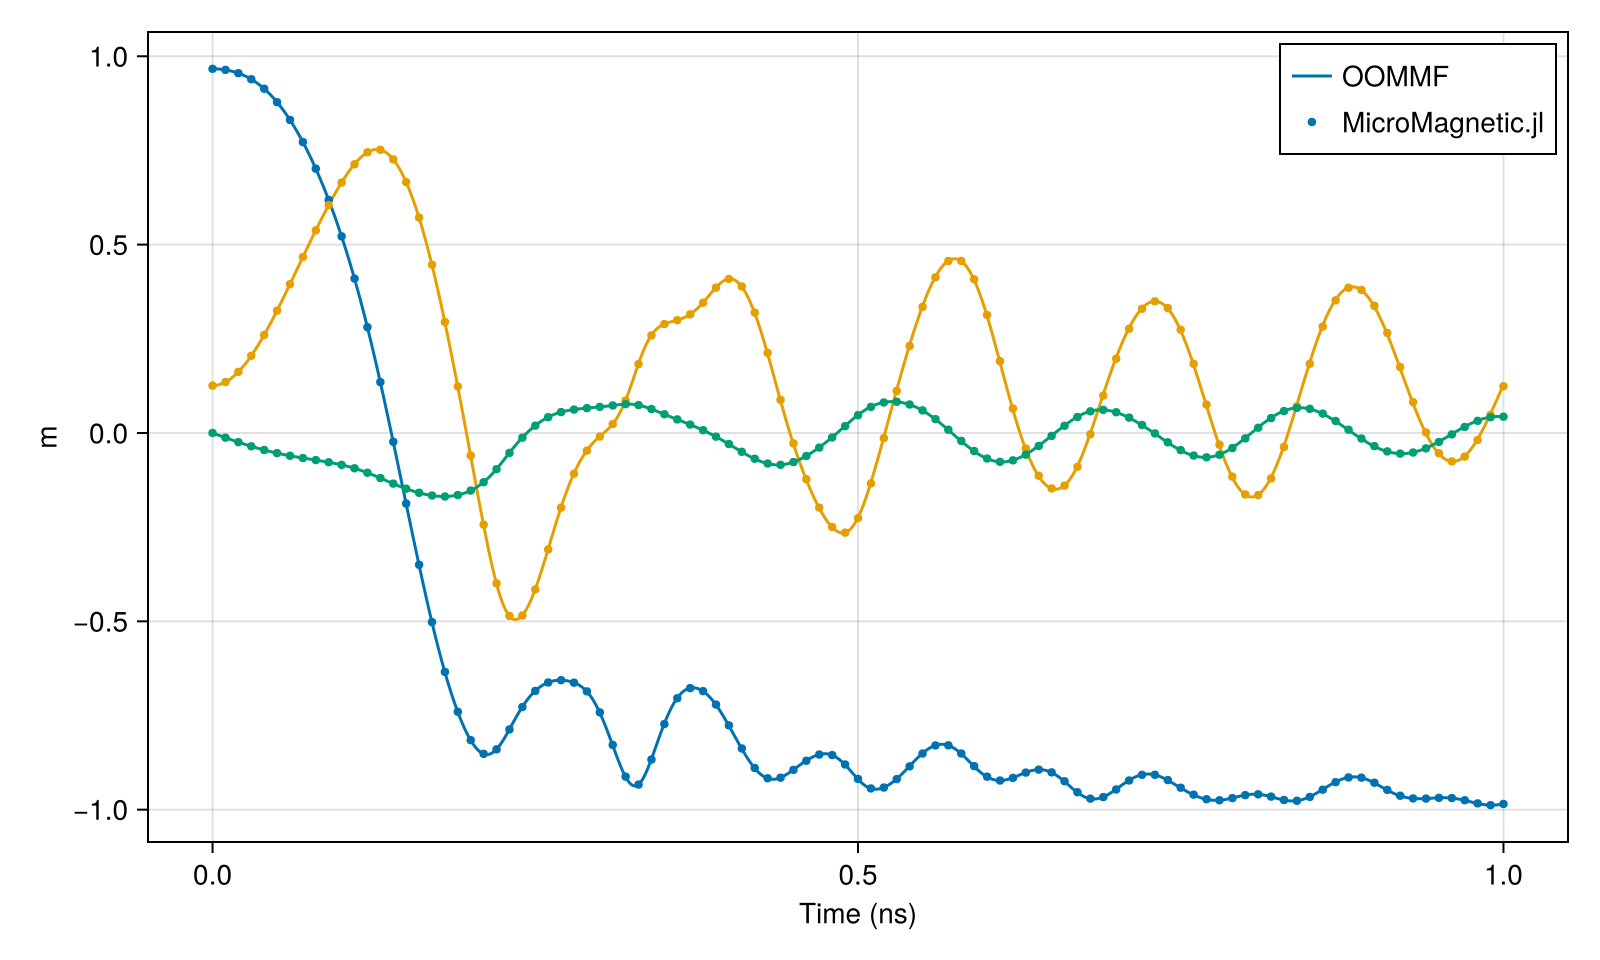

In [9]:
function plot_m_ts()
   #Load data
   data = readdlm("std4_llg.txt"; skipstart=2)
   oommf = readdlm("assets/std4_oommf.txt")

   #Create a figure for the plot
   fig = Figure(size=(800, 480))
   ax = Axis(fig[1, 1], xlabel="Time (ns)", ylabel="m")

   #Plot OOMMF results
   lines!(ax, oommf[:, 1] * 1e9, oommf[:, 2], label="OOMMF")
   lines!(ax, oommf[:, 1] * 1e9, oommf[:, 3])
   lines!(ax, oommf[:, 1] * 1e9, oommf[:, 4])

   #Plot MicroMagnetic results
   scatter!(ax, data[:, 2] * 1e9, data[:, 4], markersize=6, label="MicroMagnetic.jl")
   scatter!(ax, data[:, 2] * 1e9, data[:, 5], markersize=6)
   scatter!(ax, data[:, 2] * 1e9, data[:, 6], markersize=6)

   #Add legend to the plot
   axislegend()

   return fig
end

plot_m_ts()

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*